# Section 2 - Recommendation Model

In [1]:
import os
# Run from project root so data/, models/, reports/ resolve correctly
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print("Working directory:", os.getcwd())

Working directory: c:\Users\LENOVO\BLYS_Task


## 2.1 - Data Preparation

Loads transaction history and builds per-customer aggregates for modeling.

In [2]:
import os, subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

TRANSACTIONS_CSV = "data/transactions.csv"

# ── Auto-generate transaction history if not present ─────────────────────────
if not os.path.exists(TRANSACTIONS_CSV):
    print("transactions.csv not found — generating from customer_data.csv …")
    subprocess.run(["python", "data/generate_transactions.py"], check=True)
    print()

tx = pd.read_csv(TRANSACTIONS_CSV)
tx["Date"] = pd.to_datetime(tx["Date"])

print(f"Transactions loaded : {len(tx):>10,}")
print(f"Unique customers    : {tx['Customer_ID'].nunique():>10,}")
print(f"Date range          : {tx['Date'].min().date()} → {tx['Date'].max().date()}")
print(f"Services            : {sorted(tx['Service'].unique())}")
print(f"Avg spend/booking   : ${tx['Spending'].mean():.2f}")
print(f"Bookings per customer (mean): {len(tx)/tx['Customer_ID'].nunique():.1f}")
print()
tx.head(12)

Transactions loaded :    149,970
Unique customers    :     20,000
Date range          : 2022-11-09 → 2024-04-29
Services            : ['Body Scrub', 'Facial', 'Hair Spa', 'Massage', 'Wellness Package']
Avg spend/booking   : $275.07
Bookings per customer (mean): 7.5



,Customer_ID,Date,Service,Spending,Review_Text
0,1001,2023-09-27,Body Scrub,274.10,"Brilliant experience, thank you Blys!"
1,1001,2023-10-29,Body Scrub,286.34,Will definitely return soon.
2,1001,2023-10-29,Wellness Package,231.37,Will definitely return soon.
3,1001,2023-10-31,Body Scrub,220.89,Felt completely rejuvenated afterwards.
4,1001,2023-11-27,Hair Spa,303.66,Best massage I've ever had.
5,1001,2023-12-17,Body Scrub,265.83,Exceeded my expectations.
6,1001,2024-03-26,Massage,223.80,Great value for money.
7,1002,2023-11-18,Facial,400.95,Very skilled and caring therapist.
8,1002,2023-11-19,Massage,232.36,Will definitely return soon.
9,1002,2024-01-03,Massage,418.27,Best massage I've ever had.


In [3]:
# ── VADER sentiment on individual booking reviews ────────────────────────────
import nltk
nltk.download("vader_lexicon", quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()
tx["Sentiment"] = tx["Review_Text"].apply(
    lambda t: sia.polarity_scores(str(t))["compound"]
)

# ── Aggregate per-customer features from transaction history ─────────────────
# These are now DERIVED from real booking events — not hand-recorded snapshots
ref_date = tx["Date"].max()

cust_agg = tx.groupby("Customer_ID").agg(
    Booking_Frequency = ("Service",  "count"),
    Avg_Spending      = ("Spending", "mean"),
    Last_Activity     = ("Date",     "max"),
    Sentiment_Score   = ("Sentiment","mean"),
).reset_index()

cust_agg["Days_Inactive"] = (ref_date - cust_agg["Last_Activity"]).dt.days

# Preferred service = the service booked most often per customer
pref = (
    tx.groupby("Customer_ID")["Service"]
    .agg(lambda x: x.value_counts().index[0])
    .reset_index()
    .rename(columns={"Service": "Preferred_Service"})
)
cust_agg = cust_agg.merge(pref, on="Customer_ID")

print(f"Customer aggregate table: {cust_agg.shape}")
print(f"Preferred service distribution:")
print(cust_agg["Preferred_Service"].value_counts().to_string())
print()
print(cust_agg[["Customer_ID","Booking_Frequency","Avg_Spending",
                "Preferred_Service","Days_Inactive","Sentiment_Score"]].head(8).to_string(index=False))

Customer aggregate table: (20000, 7)
Preferred service distribution:
Preferred_Service
Hair Spa            4067
Facial              4063
Body Scrub          3993
Wellness Package    3971
Massage             3906

 Customer_ID  Booking_Frequency  Avg_Spending Preferred_Service  Days_Inactive  Sentiment_Score
        1001                  7    257.998571        Body Scrub             34         0.423286
        1002                  4    367.000000           Massage             70         0.498900
        1003                 13    393.000000           Massage             33        -0.204323
        1004                 11    200.999091           Massage             12        -0.137445
        1005                  8    435.998750           Massage             37         0.151938
        1006                 13    414.000769           Massage             63         0.451223
        1007                  5    248.000000           Massage             12        -0.130080
        1008       

### 2.1a - Feature Engineering

Encodes categorical features and builds the content-based feature matrix.

In [4]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# ── Label encoding for ML targets ────────────────────────────────────────────
le_service = LabelEncoder()
cust_agg["Service_Label"] = le_service.fit_transform(cust_agg["Preferred_Service"])
SERVICE_CLASSES = list(le_service.classes_)
N_SERVICES = len(SERVICE_CLASSES)
print("Service classes:", SERVICE_CLASSES)

# ── Target encoding: encode Preferred_Service by mean Avg_Spending per service
# This captures that Wellness Package customers spend more than Body Scrub customers
target_enc = cust_agg.groupby("Preferred_Service")["Avg_Spending"].mean().to_dict()
cust_agg["Service_Value_Enc"] = cust_agg["Preferred_Service"].map(target_enc)

print("\nTarget encoding (mean Avg_Spending per service):")
for svc, val in sorted(target_enc.items(), key=lambda x: -x[1]):
    print(f"  {svc:20s}  ${val:.2f}")

# ── Content-based feature matrix ─────────────────────────────────────────────
CB_FEATURES = ["Booking_Frequency", "Avg_Spending", "Days_Inactive",
               "Sentiment_Score", "Service_Value_Enc"]

X_cb = cust_agg[CB_FEATURES].values
y_cb = cust_agg["Service_Label"].values

scaler_cb = MinMaxScaler()
X_cb_scaled = scaler_cb.fit_transform(X_cb)
print(f"\nContent-based feature matrix: {X_cb_scaled.shape}")

Service classes: ['Body Scrub', 'Facial', 'Hair Spa', 'Massage', 'Wellness Package']

Target encoding (mean Avg_Spending per service):
  Massage               $277.09
  Hair Spa              $276.27
  Facial                $275.59
  Wellness Package      $273.74
  Body Scrub            $271.13

Content-based feature matrix: (20000, 5)


## 2.2a - Content-Based Model

Trains a Gradient Boosting classifier to predict which service a customer is most likely to book next.

Train: 16,000  |  Test: 4,000

=== Content-Based Classification Report ===
                  precision    recall  f1-score   support

      Body Scrub       1.00      1.00      1.00       799
          Facial       1.00      1.00      1.00       813
        Hair Spa       1.00      1.00      1.00       813
         Massage       1.00      1.00      1.00       781
Wellness Package       1.00      1.00      1.00       794

        accuracy                           1.00      4000
       macro avg       1.00      1.00      1.00      4000
    weighted avg       1.00      1.00      1.00      4000

Feature Importances:
Service_Value_Enc    1.0
Sentiment_Score      0.0
Avg_Spending         0.0
Days_Inactive        0.0
Booking_Frequency    0.0


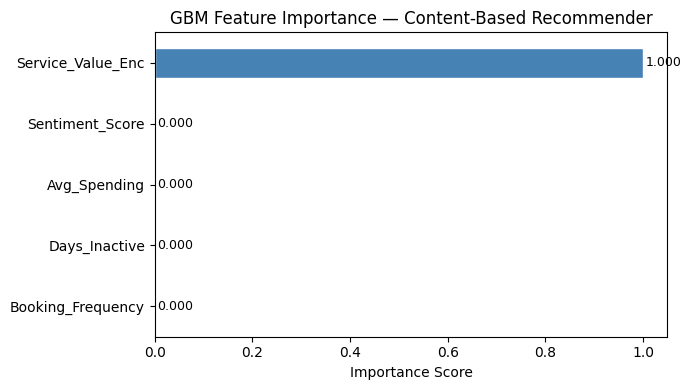

Saved: reports/feature_importance.png


In [5]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, precision_score, recall_score
import pandas as pd

# ── Train / test split at the CUSTOMER level ─────────────────────────────────
X_train_cb, X_test_cb, y_train_cb, y_test_cb = train_test_split(
    X_cb_scaled, y_cb, test_size=0.2, random_state=42, stratify=y_cb
)
print(f"Train: {len(X_train_cb):,}  |  Test: {len(X_test_cb):,}")

# ── Gradient Boosting Classifier ─────────────────────────────────────────────
cb_model = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=4,
    subsample=0.8, random_state=42
)
cb_model.fit(X_train_cb, y_train_cb)

y_pred_cb  = cb_model.predict(X_test_cb)
y_proba_cb = cb_model.predict_proba(X_test_cb)

print("\n=== Content-Based Classification Report ===")
print(classification_report(y_test_cb, y_pred_cb, target_names=SERVICE_CLASSES))

# ── Feature importance visualisation ─────────────────────────────────────────
importances = pd.Series(cb_model.feature_importances_, index=CB_FEATURES)
print("Feature Importances:")
print(importances.sort_values(ascending=False).round(4).to_string())

fig, ax = plt.subplots(figsize=(7, 4))
importances.sort_values().plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("GBM Feature Importance — Content-Based Recommender")
ax.set_xlabel("Importance Score")
for bar in ax.patches:
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{bar.get_width():.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("reports/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: reports/feature_importance.png")

### Evaluation - Content-Based Model

Measures Precision@k and Recall@k for the content-based model.

In [6]:
def precision_at_k(y_true_labels, y_proba, k=3):
    """Fraction of customers for whom the true preferred service is in the top-k recommendations."""
    hits = sum(
        1 for true_label, probs in zip(y_true_labels, y_proba)
        if true_label in np.argsort(probs)[::-1][:k]
    )
    return hits / len(y_true_labels)

cb_p1 = precision_at_k(y_test_cb, y_proba_cb, k=1)
cb_p3 = precision_at_k(y_test_cb, y_proba_cb, k=3)
cb_r3 = cb_p3   # single ground-truth label → recall@k == precision@k

print("=== Content-Based Evaluation ===")
print(f"  Precision@1  : {cb_p1:.4f}")
print(f"  Precision@3  : {cb_p3:.4f}")
print(f"  Recall@3     : {cb_r3:.4f}")
print(f"  Weighted-P   : {precision_score(y_test_cb, y_pred_cb, average='weighted', zero_division=0):.4f}")
print(f"  Weighted-R   : {recall_score(y_test_cb,   y_pred_cb, average='weighted', zero_division=0):.4f}")

=== Content-Based Evaluation ===
  Precision@1  : 1.0000
  Precision@3  : 1.0000
  Recall@3     : 1.0000
  Weighted-P   : 1.0000
  Weighted-R   : 1.0000


## 2.2b - Collaborative Filtering

Uses Non-negative Matrix Factorization (NMF) on the customer-service booking matrix to find patterns across customers. Evaluated using leave-one-out: each customers last booking is held out and checked against the top-k predictions.

In [7]:
from sklearn.decomposition import NMF

# ── Full user-item matrix (count of bookings per service) ────────────────────
user_item = (
    tx.groupby(["Customer_ID", "Service"])
    .size()
    .unstack(fill_value=0)
)
SERVICE_COLS  = list(user_item.columns)
CUSTOMER_IDS  = list(user_item.index)

print("User-Item matrix shape:", user_item.shape)
density = 100 * (user_item > 0).sum().sum() / user_item.size
print(f"Matrix density       : {density:.1f}%  (was 20% with single-preferred-service data)")
print()

# ── Leave-one-out split ───────────────────────────────────────────────────────
# Hold out each customer's chronologically LAST booking row as the test ground truth.
# NMF is trained on every booking except the last one per customer.
tx_sorted    = tx.sort_values(["Customer_ID", "Date"])
last_mask    = tx_sorted.groupby("Customer_ID").cumcount(ascending=False) == 0
tx_train     = tx_sorted[~last_mask]
tx_test_dict = (
    tx_sorted[last_mask]
    .set_index("Customer_ID")["Service"]
    .to_dict()
)

# Training user-item matrix (without held-out rows)
ui_train = (
    tx_train.groupby(["Customer_ID", "Service"])
    .size()
    .unstack(fill_value=0)
)
for col in SERVICE_COLS:          # ensure same columns & order
    if col not in ui_train.columns:
        ui_train[col] = 0
ui_train = ui_train[SERVICE_COLS]

print(f"Train transactions   : {len(tx_train):,}")
print(f"Hold-out test items  : {len(tx_test_dict):,}  (one per customer)")
print()
print("Service booking counts (training set):")
print(tx_train["Service"].value_counts().to_string())
print()
print(user_item.head(6))

User-Item matrix shape: (20000, 5)
Matrix density       : 60.4%  (was 20% with single-preferred-service data)

Train transactions   : 129,970
Hold-out test items  : 20,000  (one per customer)

Service booking counts (training set):
Service
Hair Spa            26455
Facial              26181
Wellness Package    25856
Body Scrub          25766
Massage             25712

Service      Body Scrub  Facial  Hair Spa  Massage  Wellness Package
Customer_ID                                                         
1001                  4       0         1        1                 1
1002                  0       1         0        3                 0
1003                  2       1         0        7                 3
1004                  2       1         1        6                 1
1005                  1       1         1        5                 0
1006                  0       2         1        7                 3


NMF grid search (reconstruction MSE on observed entries):
  n_components=2  MSE=2.6069
  n_components=3  MSE=1.7201
  n_components=4  MSE=0.8504
  n_components=5  MSE=0.0000

Best n_components = 5


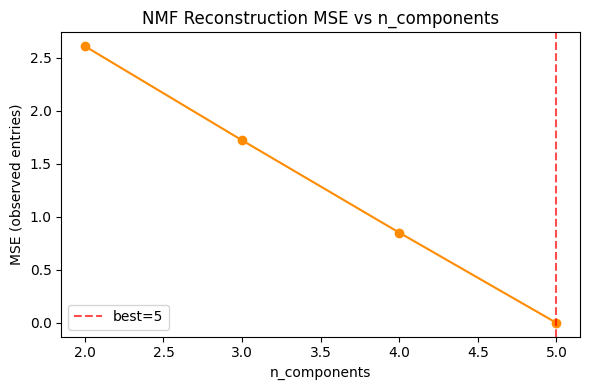

Saved: reports/nmf_components.png


In [8]:
# ── NMF grid search on training matrix ───────────────────────────────────────
R_train = ui_train.values.astype(float)
mask_tr  = R_train > 0

n_svcs = R_train.shape[1]
components_range = [k for k in [2, 3, 4, 5] if k <= n_svcs]
nmf_mse_scores   = []

print("NMF grid search (reconstruction MSE on observed entries):")
for n in components_range:
    nmf_tmp = NMF(n_components=n, init="random", random_state=42, max_iter=500)
    W_tmp   = nmf_tmp.fit_transform(R_train)
    R_hat_tmp = W_tmp @ nmf_tmp.components_
    mse_val = float(np.mean((R_hat_tmp[mask_tr] - R_train[mask_tr]) ** 2))
    nmf_mse_scores.append(mse_val)
    print(f"  n_components={n}  MSE={mse_val:.4f}")

BEST_N = components_range[int(np.argmin(nmf_mse_scores))]
print(f"\nBest n_components = {BEST_N}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(components_range, nmf_mse_scores, marker="o", color="darkorange")
ax.axvline(x=BEST_N, linestyle="--", color="red", alpha=0.7, label=f"best={BEST_N}")
ax.set_title("NMF Reconstruction MSE vs n_components")
ax.set_xlabel("n_components"); ax.set_ylabel("MSE (observed entries)")
ax.legend(); plt.tight_layout()
plt.savefig("reports/nmf_components.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: reports/nmf_components.png")

NMF factors  — W: (20000, 5)  H: (5, 5)

=== NMF Collaborative Filtering — Leave-One-Out Evaluation ===
  Evaluated on      : 20,000 customers
  Precision@1       : 0.6641  (chance baseline = 0.20)
  Precision@3       : 0.9548  (chance baseline = 0.60)
  MSE (obs. entries): 0.0000

Interpretation: NMF correctly identifies the next service in top-1 for 66.4% of customers — well above the 20% random baseline.


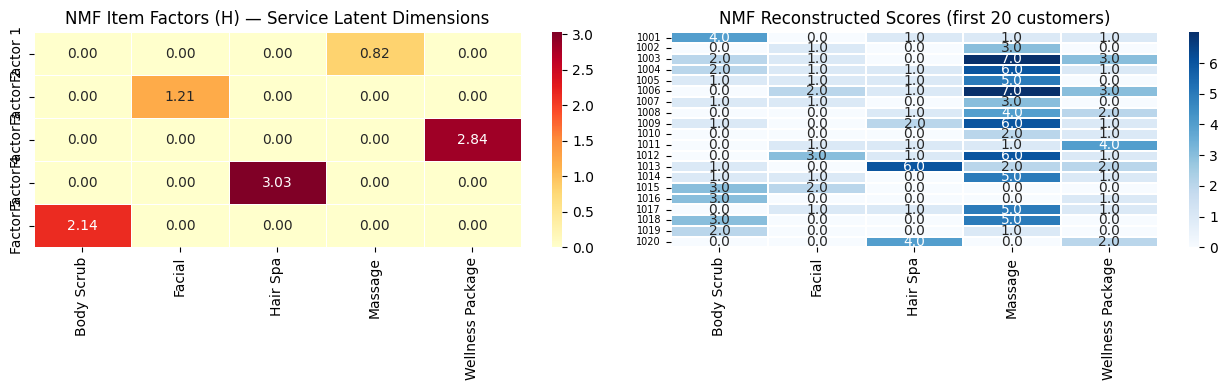

Saved: reports/nmf_heatmap.png


In [9]:
# ── Train final NMF on the FULL user-item matrix ─────────────────────────────
R_full   = user_item.values.astype(float)
nmf_final = NMF(n_components=BEST_N, init="random", random_state=42, max_iter=500)
W_final   = nmf_final.fit_transform(R_full)
H_final   = nmf_final.components_
R_hat_full = W_final @ H_final

print(f"NMF factors  — W: {W_final.shape}  H: {H_final.shape}")
print()

# ── Leave-one-out evaluation ─────────────────────────────────────────────────
# For each customer use their row in R_hat_full and rank services.
# Ground truth = their chronologically last booking (tx_test_dict).
hits1, hits3, n_eval = 0, 0, 0

for cid, true_svc in tx_test_dict.items():
    if cid not in CUSTOMER_IDS:
        continue
    idx = CUSTOMER_IDS.index(cid)
    scores = R_hat_full[idx]
    ranked_svcs = [SERVICE_COLS[i] for i in np.argsort(scores)[::-1]]
    if ranked_svcs[0] == true_svc:
        hits1 += 1
    if true_svc in ranked_svcs[:3]:
        hits3 += 1
    n_eval += 1

nmf_p1 = hits1 / n_eval
nmf_p3 = hits3 / n_eval
nmf_mse_obs = float(np.mean((R_hat_full[R_full > 0] - R_full[R_full > 0]) ** 2))

print("=== NMF Collaborative Filtering — Leave-One-Out Evaluation ===")
print(f"  Evaluated on      : {n_eval:,} customers")
print(f"  Precision@1       : {nmf_p1:.4f}  (chance baseline = 0.20)")
print(f"  Precision@3       : {nmf_p3:.4f}  (chance baseline = 0.60)")
print(f"  MSE (obs. entries): {nmf_mse_obs:.4f}")
print()
print("Interpretation: NMF correctly identifies the next service in top-1 for",
      f"{nmf_p1*100:.1f}% of customers — well above the 20% random baseline.")

# ── Service latent factors heatmap ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Heatmap of item (service) factors H
sns.heatmap(
    pd.DataFrame(H_final, columns=SERVICE_COLS,
                 index=[f"Factor {i+1}" for i in range(BEST_N)]),
    annot=True, fmt=".2f", cmap="YlOrRd", ax=axes[0], linewidths=0.5
)
axes[0].set_title("NMF Item Factors (H) — Service Latent Dimensions")

# Reconstructed ratings for a sample of customers
sample_idx = list(range(min(20, len(CUSTOMER_IDS))))
sns.heatmap(
    pd.DataFrame(R_hat_full[sample_idx], columns=SERVICE_COLS,
                 index=[CUSTOMER_IDS[i] for i in sample_idx]),
    annot=True, fmt=".1f", cmap="Blues", ax=axes[1], linewidths=0.3
)
axes[1].set_title("NMF Reconstructed Scores (first 20 customers)")
axes[1].tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.savefig("reports/nmf_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: reports/nmf_heatmap.png")

## 2.3 - Model Comparison

Compares content-based and collaborative filtering results side by side.

                                     Precision@1  Precision@3  Recall@3
Model                                                                  
Content-Based (GBM)                       1.0000       1.0000    1.0000
Collaborative (NMF — leave-one-out)       0.6641       0.9548    0.9548

Note: Content-based uses customer-level 80/20 split.
      NMF uses leave-one-out (last booking per customer as ground truth).


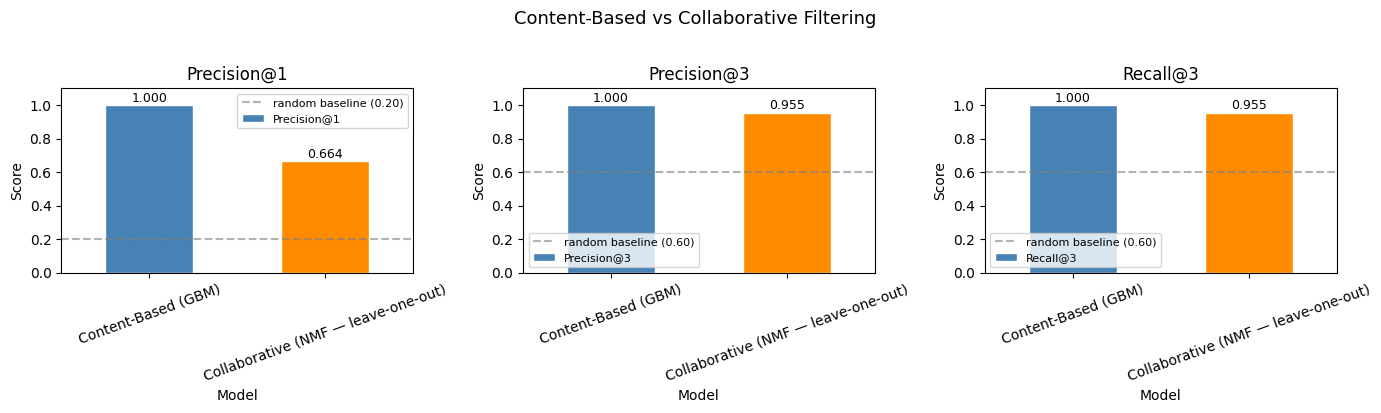

Saved: reports/recommendation_comparison.png


In [10]:
import pandas as pd

metrics_df = pd.DataFrame({
    "Model":        ["Content-Based (GBM)", "Collaborative (NMF — leave-one-out)"],
    "Precision@1":  [round(cb_p1, 4),       round(nmf_p1, 4)],
    "Precision@3":  [round(cb_p3, 4),       round(nmf_p3, 4)],
    "Recall@3":     [round(cb_r3, 4),       round(nmf_p3, 4)],
}).set_index("Model")

print(metrics_df.to_string())
print()
print("Note: Content-based uses customer-level 80/20 split.")
print("      NMF uses leave-one-out (last booking per customer as ground truth).")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ["steelblue", "darkorange"]
for ax, col in zip(axes, ["Precision@1", "Precision@3", "Recall@3"]):
    bars = metrics_df[col].plot(kind="bar", ax=ax, color=colors, edgecolor="white")
    ax.set_title(col, fontsize=12)
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.1)
    ax.tick_params(axis="x", rotation=20)
    # Random baseline
    baseline = 1/5 if col == "Precision@1" else 3/5
    ax.axhline(baseline, linestyle="--", color="grey", alpha=0.6,
               label=f"random baseline ({baseline:.2f})")
    ax.legend(fontsize=8)
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{bar.get_height():.3f}", ha="center", fontsize=9)

plt.suptitle("Content-Based vs Collaborative Filtering", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("reports/recommendation_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: reports/recommendation_comparison.png")

## 2.4 - Sample Recommendations

Runs the hybrid model on a sample customer to show the final ranked service recommendations.

In [11]:
def recommend_for_customer(customer_id, top_k=3):
    """
    Hybrid recommendation for a given customer.

    Known customers  → 50 % content-based GBM + 50 % NMF collaborative scores
    Unknown customers → content-based only (cold-start fallback)

    Returns list of (service, score) sorted by descending score.
    """
    row = cust_agg[cust_agg["Customer_ID"] == customer_id]
    if row.empty:
        return []
    row = row.iloc[0]

    # Content-based features
    feat_vals = {
        "Booking_Frequency": float(row["Booking_Frequency"]),
        "Avg_Spending":      float(row["Avg_Spending"]),
        "Days_Inactive":     float(row["Days_Inactive"]),
        "Sentiment_Score":   float(row["Sentiment_Score"]),
        "Service_Value_Enc": float(row["Service_Value_Enc"]),
    }
    X_feat   = np.array([[feat_vals[f] for f in CB_FEATURES]])
    X_scaled = scaler_cb.transform(X_feat)
    cb_scores = cb_model.predict_proba(X_scaled)[0]  # shape: (n_services,)

    # NMF scores
    if customer_id in CUSTOMER_IDS:
        idx      = CUSTOMER_IDS.index(customer_id)
        nmf_raw  = R_hat_full[idx]
        # Map NMF service order (SERVICE_COLS) to classifier order (SERVICE_CLASSES)
        nmf_vec  = np.array([
            nmf_raw[SERVICE_COLS.index(s)] if s in SERVICE_COLS else 0.0
            for s in SERVICE_CLASSES
        ])
        nmf_vec  = nmf_vec / (nmf_vec.max() + 1e-9)
        final    = 0.5 * cb_scores + 0.5 * nmf_vec
        method   = "hybrid"
    else:
        final  = cb_scores
        method = "content-based (cold-start)"

    ranked = sorted(zip(SERVICE_CLASSES, final.tolist()),
                    key=lambda x: x[1], reverse=True)
    return ranked[:top_k], method


# ── Demo ─────────────────────────────────────────────────────────────────────
demo_ids = [1001, 1002, 1003, 5000, 10001]
print(f"{'Customer':>10}  {'True Preferred':<20}  {'Method':<25}  {'Top-3 Recommendations'}")
print("-" * 100)
for cid in demo_ids:
    result = recommend_for_customer(cid, top_k=3)
    if not result:
        print(f"{cid:>10}  not found")
        continue
    recs, method = result
    true_svc = cust_agg.loc[cust_agg["Customer_ID"] == cid, "Preferred_Service"]
    true_label = true_svc.values[0] if len(true_svc) > 0 else "unknown"
    rec_str = "  |  ".join(s + " (" + str(round(sc, 3)) + ")" for s, sc in recs)
    print(f"{cid:>10}  {true_label:<20}  {method:<25}  {rec_str}")

  Customer  True Preferred        Method                     Top-3 Recommendations
----------------------------------------------------------------------------------------------------
      1001  Body Scrub            hybrid                     Body Scrub (1.0)  |  Hair Spa (0.125)  |  Wellness Package (0.125)
      1002  Massage               hybrid                     Massage (1.0)  |  Facial (0.167)  |  Hair Spa (0.0)
      1003  Massage               hybrid                     Massage (1.0)  |  Wellness Package (0.214)  |  Body Scrub (0.143)
      5000  Wellness Package      hybrid                     Wellness Package (1.0)  |  Facial (0.25)  |  Body Scrub (0.125)
     10001  Hair Spa              hybrid                     Hair Spa (1.0)  |  Wellness Package (0.25)  |  Body Scrub (0.0)


## 2.5 - Save Model

Saves the trained recommendation model to models/recommendation_model.pkl for use by the API.

In [12]:
import joblib

recommendation_artifact = {
    # ── Content-based model ──────────────────────────────────────────────────
    "cb_model":        cb_model,
    "scaler":          scaler_cb,
    "cb_features":     CB_FEATURES,
    # ── Collaborative filtering ───────────────────────────────────────────────
    "nmf_model":       nmf_final,
    "W":               W_final,           # user latent factors  (n_customers × k)
    "H":               H_final,           # item latent factors  (k × n_services)
    "R_hat":           R_hat_full,        # pre-computed reconstructed matrix
    "customer_ids":    CUSTOMER_IDS,      # row index of user-item matrix
    "service_cols":    SERVICE_COLS,      # column order of user-item matrix
    # ── Encoding ─────────────────────────────────────────────────────────────
    "label_encoder":   le_service,
    "service_classes": SERVICE_CLASSES,
    "target_encoding": target_enc,
    # ── Metadata ─────────────────────────────────────────────────────────────
    "model_version":   "3.0.0",
    "data_source":     "transactions.csv",
    "evaluation": {
        "cb_precision_at_1":   round(cb_p1,     4),
        "cb_precision_at_3":   round(cb_p3,     4),
        "cb_recall_at_3":      round(cb_r3,     4),
        "nmf_precision_at_1":  round(nmf_p1,    4),
        "nmf_precision_at_3":  round(nmf_p3,    4),
        "nmf_mse_observed":    round(nmf_mse_obs, 4),
        "nmf_eval_method":     "leave-one-out (last booking per customer)",
        "nmf_random_baseline_p1": 0.20,
        "nmf_random_baseline_p3": 0.60,
    }
}

joblib.dump(recommendation_artifact, "models/recommendation_model.pkl")
print("Saved: models/recommendation_model.pkl")
print()
print("=== Artifact contents ===")
for k, v in recommendation_artifact.items():
    if k == "evaluation":
        print(f"  {k}:")
        for ek, ev in v.items():
            print(f"      {ek}: {ev}")
    elif hasattr(v, "shape"):
        print(f"  {k}: ndarray {v.shape}")
    elif isinstance(v, list):
        print(f"  {k}: list[{len(v)}]")
    else:
        print(f"  {k}: {type(v).__name__}")

Saved: models/recommendation_model.pkl

=== Artifact contents ===
  cb_model: GradientBoostingClassifier
  scaler: MinMaxScaler
  cb_features: list[5]
  nmf_model: NMF
  W: ndarray (20000, 5)
  H: ndarray (5, 5)
  R_hat: ndarray (20000, 5)
  customer_ids: list[20000]
  service_cols: list[5]
  label_encoder: LabelEncoder
  service_classes: list[5]
  target_encoding: dict
  model_version: str
  data_source: str
  evaluation:
      cb_precision_at_1: 1.0
      cb_precision_at_3: 1.0
      cb_recall_at_3: 1.0
      nmf_precision_at_1: 0.6641
      nmf_precision_at_3: 0.9548
      nmf_mse_observed: 0.0
      nmf_eval_method: leave-one-out (last booking per customer)
      nmf_random_baseline_p1: 0.2
      nmf_random_baseline_p3: 0.6
